# Python Companion

The lectures use Python without stopping to explain it: class time goes to the
finance, and the AI writes most of the code. This notebook is where the code
gets explained.

It is not a Python course. It covers only what actually appears in the lecture
notebooks, in the order it first appears, and every entry points back to where
it was used. When a line in a lecture looks like magic, look it up here.

Each entry has three parts:

- **The line**, exactly as it appears in class
- **What it does**, piece by piece, usually on a table small enough to see all of
- **📍 Used in**, the lecture and section, linked

Run the Setup cell first, then the entries in order — later entries use the
data loaded by earlier ones. The code cells are short on purpose. Change
something and re-run: that is the fastest way to find out what a line does.

## 📋 Contents

**From *The Workflow, and What a Return Is***

1. [Libraries, and the Setup cell](#imports)
2. [Variables and f-strings](#fstrings)
3. [Calling a function: `yf.download`, `.iloc`](#yfinance)
4. [Fama-French from the internet: `web.DataReader`](#datareader)
5. [Fixing the dates: `to_timestamp` and `MonthEnd`](#monthend)
6. [Columns: `ff['RF']` and `ff[['Mkt-RF', 'RF']]`](#columns)
7. [The course panel: `pd.read_parquet`](#parquet)
8. [One stock out of the panel: masks and `set_index`](#onestock)
9. [Whole-column arithmetic: `.prod()`, `.mean()`, `.std()`](#vector)
10. [Lining up two series by date: `.reindex`, `.dropna`](#align)
11. [The memo and the submission cell](#submission)

**From *The Panel and Portfolio Mathematics***

12. [The panel is long](#long)
13. [`scipy.stats`: skewness and kurtosis](#scipy)
14. [A figure: `fig, ax = plt.subplots()`](#figure)
15. [`groupby`, part one: one number per stock](#groupby1)
16. [`.rename`, `.idxmin`, `.strftime`](#idxmin)
17. [`.shift(1)`: last month's value](#shift)
18. [`groupby('permno')['me'].shift(1)`: last month's value, per stock](#groupshift)
19. [One month's portfolio by hand: weights, `@`, `np.average`](#weights)
20. [`groupby`, part two: one number per month, and `lambda`](#groupby2)
21. [Growth of \$1 on a log scale](#logscale)
22. [A `for` loop and a dictionary](#forloop)
23. [`def`: a function with a name](#def)

**From *Sorts, Breakpoints, and Long-Short Portfolios***

24. [`pd.read_csv`, and a base address](#readcsv)
25. [`.loc[rows, column]`](#loc2)
26. [`.quantile`, and `np.exp`](#quantile)
27. [`.diff()`, `!=`, and slices](#diff)
28. [`merge`, and `.notna()`](#merge)
29. [`.transform`, and `pd.qcut`](#qcut)
30. [Grouping by two columns, and `.unstack()`](#unstack)
31. [`range`, and two panels in one figure](#subplots2)
32. [`pd.set_option`, and sorting by a column](#setoption)

---

## 🛠️ Setup

In [1]:
#@title Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 4.5]
plt.rcParams['font.size'] = 11
import warnings; warnings.filterwarnings('ignore')

print("✅ Ready")

✅ Ready


---

## From *The Workflow, and What a Return Is*

### 1. Libraries, and the Setup cell <a id="imports"></a>

> ```python
> import numpy as np
> import pandas as pd
> import matplotlib.pyplot as plt
> ```

Python on its own knows arithmetic, text and lists. Almost everything else
comes from **libraries** — code other people wrote, which you load with
`import`. Three do nearly all the work in this course:

| Library | What it is for | You will see |
|---|---|---|
| `numpy` | numbers and arrays: square roots, weighted averages | `np.sqrt(12)`, `np.average(...)` |
| `pandas` | tables with labelled rows and columns | `pd.read_parquet(...)`, `panel.groupby(...)` |
| `matplotlib` | figures | `plt.subplots()`, `ax.plot(...)` |

`as np` is a nickname. Without it you would type `numpy.sqrt(12)` every time;
with it, `np.sqrt(12)`. The nicknames `np`, `pd` and `plt` are universal —
every example online and everything the AI writes uses them.

The rest of the Setup cell is cosmetic:

- `%matplotlib inline` is not Python. It is a notebook command that puts each
  figure under the cell that made it.
- `plt.style.use(...)` and `plt.rcParams[...]` set how figures look by default.
- `warnings.filterwarnings('ignore')` hides warning messages. That keeps the
  output clean, and it also hides warnings you might have wanted. If something
  behaves strangely, delete that line and re-run.
- `#@title` is a Colab label that names the cell and lets you collapse it. To
  Python it is a comment, like anything else after `#`.

📍 **Used in:** the Setup cell of every lecture, starting with
[*The Workflow, and What a Return Is*](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#setup-cell).

In [2]:
print(np.sqrt(12))                       # numpy: a square root
print(pd.Series([0.10, -0.05, 0.02]))    # pandas: a labelled column of numbers

3.4641016151377544
0    0.10
1   -0.05
2    0.02
dtype: float64


### 2. Variables and f-strings <a id="fstrings"></a>

> ```python
> STOCK      = "AAPL"
> INVESTMENT = 1000
> print(f"${INVESTMENT:,} in {STOCK} from {BIRTH_DATE} to {END_DATE}")
> ```

`=` stores a value under a name. `"AAPL"` in quotes is text (a *string*);
`1000` without quotes is a number. The capital letters are a convention for
"settings you are meant to edit", nothing more.

The `f` before the quotes makes an **f-string**: anything inside `{ }` is
replaced by its value, and after a colon you can say how to format it. Nearly
every `print` in the course uses one. The codes worth knowing:

| Code | Does | with `x = 0.08443` |
|---|---|---|
| `{x}` | as is | `0.08443` |
| `{x:.2f}` | 2 decimals | `0.08` |
| `{x:.1%}` | percent, 1 decimal | `8.4%` |
| `{x:+.2%}` | always show the sign | `+8.44%` |
| `{x:>9.1%}` | right-aligned in 9 characters | `     8.4%` |
| `{n:,}` | thousands separator | `85,428` |

Dates have their own codes: `{d:%Y-%m}` gives `1995-06`, `{d:%B %Y}` gives
`June 1995`.

📍 **Used in:** [Live Demo, Step 1 — Specify](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#step-1-specify), and every
`print` after it.

In [3]:
STOCK      = "AAPL"
INVESTMENT = 1000
x = 0.08443

print(f"${INVESTMENT:,} in {STOCK}")
print(f"[{x}]  [{x:.2f}]  [{x:.1%}]  [{x:+.2%}]  [{x:>9.1%}]")

d = pd.Timestamp('1995-06-30')
print(f"{d:%Y-%m}   {d:%B %Y}")

$1,000 in AAPL
[0.08443]  [0.08]  [8.4%]  [+8.44%]  [     8.4%]
1995-06   June 1995


### 3. Calling a function: `yf.download`, `.iloc` <a id="yfinance"></a>

> ```python
> px  = yf.download(STOCK, start=BIRTH_DATE, end=END_DATE, progress=False, auto_adjust=True)['Close']
> tot = float(px.iloc[-1] / px.iloc[0]) - 1
> ```

A function takes inputs in parentheses and hands back a result. Inputs come in
two ways: by **position** — `STOCK` comes first, so `yf.download` knows it is
the ticker — and by **keyword**, like `start=...` and `end=...`. A keyword you
leave out takes a default value.

That default is what the Live Demo's check cell is about. `auto_adjust`
decides whether the prices include dividends. If the AI's code leaves it out,
you get whatever the library's default happens to be. Two calls that differ in
one keyword give different answers, and both run without complaint.

`['Close']` picks one column out of what came back. `.iloc` picks rows by
**position**: `.iloc[0]` is the first row, `.iloc[-1]` the last (negative
positions count from the end). So `px.iloc[-1] / px.iloc[0] - 1` is last price
over first price, minus one: the return over the whole window. `float(...)`
turns the result into a plain number.

The check cell wraps all of this in `try:` … `except Exception:`. If anything
inside `try` fails — Yahoo is down, no internet — Python runs the `except` part
instead of stopping with an error.

📍 **Used in:** [Live Demo, Step 2 — the 🔒 Check cell](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#step-2-implement).

In [4]:
# four month-end prices, made up
px = pd.Series([100.0, 104.0, 98.0, 120.0],
               index=pd.to_datetime(['2020-01-31', '2020-02-29', '2020-03-31', '2020-04-30']))
print(px, "\n")

print("first :", px.iloc[0])
print("last  :", px.iloc[-1])
print(f"return: {px.iloc[-1] / px.iloc[0] - 1:.1%}")

2020-01-31    100.0
2020-02-29    104.0
2020-03-31     98.0
2020-04-30    120.0
dtype: float64 

first : 100.0
last  : 120.0
return: 20.0%


### 4. Fama-French from the internet: `web.DataReader` <a id="datareader"></a>

> ```python
> import pandas_datareader.data as web
> ff = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1980-01-01')[0]
> ```

`pandas_datareader` downloads data from public sources straight into pandas.
The source here is `'famafrench'`, Ken French's data library, and the dataset
is his monthly factors — which include the risk-free rate `RF` and the
market's excess return `Mkt-RF`.

What comes back is not one table but a **dictionary** of them: labelled boxes.
Box `0` holds the monthly table, box `1` the annual one, and `'DESCR'` a text
description. The `[0]` at the end of the line opens box 0.

📍 **Used in:** [Excess Returns and the Units Trap](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#excess); again in
[*The Panel and Portfolio Mathematics*](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#but-ge-is-one-company) and its Challenge.

In [5]:
import pandas_datareader.data as web

raw = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start='1980-01-01')
print(type(raw).__name__, "with keys", list(raw.keys()), "\n")

ff = raw[0]          # box 0: the monthly table
ff.head(3)

dict with keys [0, 1, 'DESCR'] 



,Mkt-RF,SMB,HML,RF
Date,,,,
1980-01,5.50,1.62,1.85,0.80
1980-02,-1.23,-1.86,0.59,0.89
1980-03,-12.90,-6.70,-0.96,1.21


### 5. Fixing the dates: `to_timestamp` and `MonthEnd` <a id="monthend"></a>

> ```python
> ff.index = pd.to_datetime(ff.index.to_timestamp()) + pd.offsets.MonthEnd(0)
> ff = ff / 100
> ```

The most cryptic line so far. It changes the **index** — the row labels,
printed down the left of the table — and nothing else.

Ken French labels each row with a *month*, `1980-01`, which pandas stores as a
`Period`. The course panel labels each row with a *date*, the last day of the
month: `1980-01-31`. Two tables only line up when their labels are the same
kind of thing (entry 10 shows why), so the line converts one into the other:

1. `.to_timestamp()` turns each month into a date — its **first** day,
   `1980-01-01`.
2. `+ pd.offsets.MonthEnd(0)` rolls each date forward to the end of its month.
   The `0` means "if it is already a month-end, leave it there".

The `pd.to_datetime(...)` wrapped around step 1 makes sure pandas treats the
result as dates. Here it changes nothing you can see.

Then `/ 100`. Ken French reports percent, so `0.65` means 0.65%. Dividing the
whole table by 100 puts it in decimals, the same units as `ret` in the panel.
Leaving it out is the units trap from the lecture.

📍 **Used in:** [Excess Returns and the Units Trap](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#the-trap), and every
notebook that loads `ff`.

In [6]:
idx = ff.index[:3]
print("as delivered      :", list(idx.astype(str)), "  a", type(idx).__name__)

step1 = idx.to_timestamp()
print("1. to_timestamp() :", list(step1.strftime('%Y-%m-%d')))

step2 = pd.to_datetime(step1) + pd.offsets.MonthEnd(0)
print("2. + MonthEnd(0)  :", list(step2.strftime('%Y-%m-%d')))

# the line from the lecture, then the units
ff.index = pd.to_datetime(ff.index.to_timestamp()) + pd.offsets.MonthEnd(0)
ff = ff / 100
ff.head(3)

as delivered      : ['1980-01', '1980-02', '1980-03']   a PeriodIndex
1. to_timestamp() : ['1980-01-01', '1980-02-01', '1980-03-01']
2. + MonthEnd(0)  : ['1980-01-31', '1980-02-29', '1980-03-31']


,Mkt-RF,SMB,HML,RF
Date,,,,
1980-01-31,0.0550,0.0162,0.0185,0.0080
1980-02-29,-0.0123,-0.0186,0.0059,0.0089
1980-03-31,-0.1290,-0.0670,-0.0096,0.0121


### 6. Columns: `ff['RF']` and `ff[['Mkt-RF', 'RF']]` <a id="columns"></a>

> ```python
> print(ff[['Mkt-RF', 'RF']].head(3).to_string())
> print(f"mean RF = {ff['RF'].mean():.4f}")
> ```

A pandas table is a **DataFrame**. Each column on its own is a **Series**: one
column of values with the row labels attached.

- **One** name in brackets, `ff['RF']`, gives a Series.
- A **list** of names, `ff[['Mkt-RF', 'RF']]`, gives a smaller DataFrame. The
  outer brackets select; the inner ones make the list.

`.head(3)` keeps the first three rows. `.to_string()` turns the table into
plain text, so `print` shows all of it neatly. `.mean()` averages a column;
`.std()`, `.min()` and `.max()` work the same way.

You will also see `panel.permno` in place of `panel['permno']`. It is the same
column. The dot is shorter, but it only works when the name has no spaces or
symbols — `ff.Mkt-RF` would be read as `ff.Mkt` minus `RF` — and it cannot
create a new column.

📍 **Used in:** [Excess Returns and the Units Trap](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#the-trap).

In [7]:
rf = ff['RF']
print(type(rf).__name__)
print(rf.head(3), "\n")

two = ff[['Mkt-RF', 'RF']]
print(type(two).__name__)
print(two.head(3).to_string(), "\n")

print(f"mean RF = {ff['RF'].mean():.4f}   per month, in decimals")

Series
Date
1980-01-31    0.0080
1980-02-29    0.0089
1980-03-31    0.0121
Name: RF, dtype: float64 

DataFrame
            Mkt-RF      RF
Date                      
1980-01-31  0.0550  0.0080
1980-02-29 -0.0123  0.0089
1980-03-31 -0.1290  0.0121 

mean RF = 0.0033   per month, in decimals


### 7. The course panel: `pd.read_parquet` <a id="parquet"></a>

> ```python
> URL = ("https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/panel_backbone_1980_2000.parquet")
> panel = pd.read_parquet(URL)
> ```

Parquet is a file format for tables. It is smaller and much faster to load than
a CSV or a spreadsheet, and it remembers each column's type, so dates arrive as
dates. `pd.read_parquet` reads one from a file or, as here, straight from a web
address.

The parentheses around the address let it be split across lines. Python glues
two strings that sit side by side into one — `"abc" "def"` is `"abcdef"` — and
the Challenge solution uses that to keep the line short.

Then the first look at what you loaded:

- `len(panel)` — the number of rows
- `panel.permno.nunique()` — the number of *distinct* values in a column
- `.min()` and `.max()` (entry 6) work on dates too; `.date()` drops the time
  of day for printing
- `list(panel.columns)` — the column names

📍 **Used in:** [Challenge: General Electric vs the Market](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#challenge-general-electric-vs-the-market);
again at the top of [The Stacked Panel](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#the-stacked-panel).

In [8]:
URL = ("https://raw.githubusercontent.com/amoreira2/UG54/"
       "refs/heads/main/assets/data/panel_backbone_1980_2000.parquet")
panel = pd.read_parquet(URL)

print(f"{len(panel):,} rows | {panel.permno.nunique():,} stocks | {panel.date.nunique()} months")
print(f"{panel.date.min().date()} to {panel.date.max().date()}")
print("columns:", list(panel.columns))
panel.head()

1,517,174 rows | 17,800 stocks | 252 months
1980-01-31 to 2000-12-31
columns: ['permno', 'date', 'ret', 'me', 'prc', 'exchcd', 'shrcd']


,permno,date,ret,me,prc,exchcd,shrcd
0,10000,1986-02-28,-0.257143,11960.00000,-3.25000,3,10
1,10000,1986-03-31,0.365385,16330.00000,-4.43750,3,10
2,10000,1986-04-30,-0.098592,15172.00000,-4.00000,3,10
3,10000,1986-05-31,-0.222656,11793.87793,-3.10938,3,10
4,10000,1986-06-30,-0.005025,11734.59375,-3.09375,3,10


### 8. One stock out of the panel: masks and `set_index` <a id="onestock"></a>

> ```python
> ge = panel[panel.permno == 12060].set_index('date')['ret'].sort_index()
> ```

Read a chain like this left to right. Each step hands its result to the next.

1. `panel.permno == 12060` compares every row's `permno` with 12060 and gives
   a column of `True`/`False` — a **mask**. (`==` compares; a single `=` would
   store.)
2. `panel[mask]` keeps the rows where the mask is `True`: GE's 252 months.
3. `.set_index('date')` makes the date the row label, so each return is
   labelled by its month.
4. `['ret']` keeps just the return column, as a Series.
5. `.sort_index()` puts it in date order.

📍 **Used in:** [Challenge Solutions](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#solutions); again in
[What Returns Actually Look Like](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#distributions) and
[Timing is everything](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#timing-is-everything).

In [9]:
mask = panel.permno == 12060
print(mask.head(3), "\n")
print(f"{mask.sum()} rows are True\n")        # True counts as 1 when you add

ge = panel[mask].set_index('date')['ret'].sort_index()
print(ge.head(3))

0    False
1    False
2    False
Name: permno, dtype: bool 

252 rows are True

date
1980-01-31    0.086420
1980-02-29   -0.073636
1980-03-31   -0.042289
Name: ret, dtype: float32


### 9. Whole-column arithmetic: `.prod()`, `.mean()`, `.std()` <a id="vector"></a>

> ```python
> ge_total_return = (1 + ge).prod() - 1
> ge_ann_excess   = ge_excess.mean() * 12
> ge_ann_vol      = ge_excess.std()  * np.sqrt(12)
> ```

Arithmetic on a Series happens to every element at once. `1 + ge` adds one to
each of GE's 252 returns, with no loop. Then:

- `.prod()` multiplies all the elements together, so `(1 + ge).prod() - 1` is
  the compounded return.
- `.sum()` adds them up. Summing returns is pitfall 4 in the lecture's
  checklist: it runs, and it answers a different question.
- `.cumprod()` is the running product — the value of \$1 month by month rather
  than only at the end. Growth-of-\$1 plots draw it (entry 21).
- Times 12 and times `np.sqrt(12)`, the monthly `.mean()` and `.std()` (entry 6)
  become annual numbers.

📍 **Used in:** the [Pitfall Checklist for Returns](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#pitfalls) and the
[Challenge Solutions](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#solutions).

In [10]:
r = pd.Series([0.10, -0.10, 0.10, -0.10])       # four months: up, down, up, down

print("1 + r      :", (1 + r).tolist())
print(f"sum        : {r.sum():+.4f}")
print(f"compounded : {(1 + r).prod() - 1:+.4f}")
print("cumprod    :", (1 + r).cumprod().round(4).tolist())

1 + r      : [1.1, 0.9, 1.1, 0.9]
sum        : +0.0000
compounded : -0.0199
cumprod    : [1.1, 0.99, 1.089, 0.9801]


### 10. Lining up two series by date: `.reindex`, `.dropna` <a id="align"></a>

> ```python
> rf        = ff['RF'].reindex(ge.index)
> ge_excess = (ge - rf).dropna()
> ```

When you subtract one Series from another, pandas pairs them by **label**, not
by position: GE's June 1995 return meets June 1995's risk-free rate, wherever
each one sits. A label found in only one of the two gives `NaN` — "not a
number", pandas' marker for a missing value.

`.reindex(ge.index)` makes the pairing explicit. It returns `RF` at exactly
GE's dates, in GE's order, with `NaN` for any date Ken French doesn't have.
`.dropna()` then drops the rows that are missing.

This is why entry 5 fixed the dates. Had `ff` still been labelled `1980-01`
and the panel `1980-01-31`, no label would match: every excess return would be
`NaN`, with no error to tell you.

📍 **Used in:** [Challenge Solutions](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#solutions), Q2 and Q3.

In [11]:
a = pd.Series([0.05, 0.02, -0.01],
              index=pd.to_datetime(['1995-04-30', '1995-05-31', '1995-06-30']))
b = pd.Series([0.004, 0.005],                          # other order, April missing
              index=pd.to_datetime(['1995-06-30', '1995-05-31']))

print(a - b, "\n")             # paired by date, not by position
print((a - b).dropna(), "\n")
print(b.reindex(a.index))      # b, at a's dates

1995-04-30      NaN
1995-05-31    0.015
1995-06-30   -0.014
Freq: ME, dtype: float64 

1995-05-31    0.015
1995-06-30   -0.014
Freq: ME, dtype: float64 

1995-04-30      NaN
1995-05-31    0.005
1995-06-30    0.004
dtype: float64


### 11. The memo and the submission cell <a id="submission"></a>

> ```python
> MEMO = """
> Write your memo here. Don't delete the surrounding triple quotes.
> """
> ```

Triple quotes make a string that can run over several lines, which is why the
memo sits inside them. Delete one of the quotes and Python can no longer tell
where the text ends, so the cell stops with a `SyntaxError`.

The submission cell is one you run but never edit. It does three things:

1. `missing = [v for v in required if v not in globals()]` is a **list
   comprehension**: go through each name `v` in `required`, and keep the ones
   the notebook doesn't know. `globals()` is everything the notebook has in
   memory right now. So a variable counts only if the cell that defines it has
   been **run** in this session. Typing it isn't enough, and restarting the
   runtime forgets everything.
2. If anything is missing, `raise NameError(...)` stops with a message that
   lists it.
3. Otherwise it packs your answers and memo into one line of text: the token
   you paste into the form.

📍 **Used in:** [Submission](https://amoreira2.github.io/UG54/chapters/Finance/L1_Welcome_Returns_AI.html#submit), at the end of every lecture.

In [12]:
x = 1
MEMO = """
Two lines
of memo.
"""
required = ['x', 'MEMO', 'a_name_never_defined']

missing = [v for v in required if v not in globals()]
print("missing:", missing, "\n")

print(repr(MEMO))              # repr shows the line breaks as \n
print(repr(MEMO.strip()))      # .strip() trims them from both ends

missing: ['a_name_never_defined'] 

'\nTwo lines\nof memo.\n'
'Two lines\nof memo.'


---

## From *The Panel and Portfolio Mathematics*

### 12. The panel is long <a id="long"></a>

> ```python
> print(f"average of {len(panel)/panel.date.nunique():.0f} stocks per month")
> ```

The panel has one row per stock per month, stacked. Almost every question in
the course starts from one of two slices of it:

- **Fix a stock, follow it through time** — a time series.
  `panel[panel.permno == 12060]`, entry 8.
- **Fix a month, look across stocks** — a cross-section.
  `panel[panel.date == '1995-06-30']`.

The second filter compares dates with a string. pandas reads `'1995-06-30'` as
a date for the comparison, so you don't have to build one.

Most of the code in this lecture takes the second slice for *every* month at
once. That is what `groupby` is for (entries 15 and 20).

📍 **Used in:** [The Stacked Panel](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#the-stacked-panel) and
[Long, not wide](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#long-not-wide).

In [13]:
june = panel[panel.date == '1995-06-30']
print(f"June 1995: {len(june):,} stocks\n")
print(june.head(3).to_string(), "\n")

print(f"average of {len(panel)/panel.date.nunique():.0f} stocks per month")

June 1995: 6,690 stocks

     permno       date       ret       me    prc  exchcd  shrcd
128   10001 1995-06-30  0.060318  18595.5   8.25       3     11
307   10002 1995-06-30 -0.031111  38987.0 -13.00       3     11
486   10003 1995-06-30  0.523810  20168.0   4.00       3     11 

average of 6021 stocks per month


### 13. `scipy.stats`: skewness and kurtosis <a id="scipy"></a>

> ```python
> from scipy import stats
> print(f"skewness {stats.skew(ge):.2f}   excess kurtosis {stats.kurtosis(ge):.2f}")
> ```

`scipy` is a fourth library, for statistics. `from scipy import stats` loads
just its `stats` part, so you write `stats.skew(...)` rather than
`scipy.stats.skew(...)`.

- `stats.skew(x)` measures asymmetry. Positive means a long right tail: rare,
  large gains.
- `stats.kurtosis(x)` measures how fat the tails are. By default it reports
  **excess** kurtosis, with 3 already subtracted, so a normal distribution
  scores 0. That default is why the lecture can print "(normal: 0)" beside it.
- `stats.norm.pdf(t)` is the height of the bell curve at each point in `t`:
  the dashed line in the lecture's histograms (entry 14).

One missing value makes these return `nan`, which is why the lecture's GE line
ends in `.dropna()`.

📍 **Used in:** [What Returns Actually Look Like](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#distributions).

In [14]:
from scipy import stats

ge = panel[panel.permno == 12060].set_index('date')['ret'].dropna()      # GE, 252 months

print(f"skewness          {stats.skew(ge):6.2f}")
print(f"excess kurtosis   {stats.kurtosis(ge):6.2f}    the default: 3 already subtracted")
print(f"kurtosis          {stats.kurtosis(ge, fisher=False):6.2f}    fisher=False: the raw number\n")

print("with a missing value:", stats.skew(pd.Series([0.10, np.nan, -0.20, 0.05])))

skewness            0.00
excess kurtosis     0.54    the default: 3 already subtracted
kurtosis            3.54    fisher=False: the raw number

with a missing value: nan


### 14. A figure: `fig, ax = plt.subplots()` <a id="figure"></a>

> ```python
> fig, ax = plt.subplots(figsize=(7.5, 3.4))
> ax.hist(z, bins=40, density=True, alpha=0.65, color='steelblue', label='GE')
> ax.plot(t, stats.norm.pdf(t), 'k--', lw=1.6, label='Normal')
> ax.set_xlabel('standard deviations from the mean'); ax.legend()
> plt.tight_layout(); plt.show()
> ```

Every figure in the course is built the same way.

- `plt.subplots(...)` creates a figure and hands back two things: `fig`, the
  whole image, and `ax`, the plotting area inside it. `fig, ax = ...` stores
  them under two names at once. `figsize=(width, height)` is in inches.
- You draw on `ax`: `ax.hist(...)` for a histogram, `ax.plot(x, y)` for a line.
  `bins=40` is the number of bars. `density=True` scales the bars so their total
  area is one, which is what lets a histogram share an axis with a bell curve.
  `alpha` is transparency. `'k--'` means black (`k`), dashed (`--`), and `lw`
  is the line width.
- You label: `ax.set_xlabel`, `ax.set_title`, and `ax.legend()`, which lists
  every `label=` you gave.
- `plt.tight_layout(); plt.show()` tidies the margins and draws it. The
  semicolon lets two statements share a line; it only saves space.

Two lines before the figure prepare the data. `z = (ge - ge.mean()) / ge.std()`
rescales the returns into standard deviations from their mean, and
`np.linspace(-4, 4, 300)` makes 300 evenly spaced points from −4 to 4 — the
x-values at which the bell curve is drawn.

📍 **Used in:** [What Returns Actually Look Like](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#distributions), and every
figure after it.

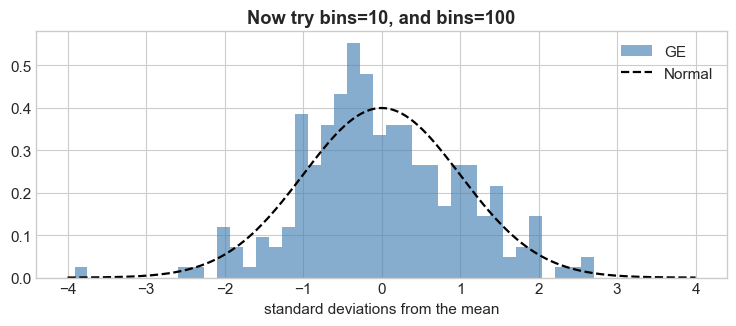

In [15]:
z = (ge - ge.mean()) / ge.std()        # GE's returns, in standard deviations
t = np.linspace(-4, 4, 300)            # x-values for the bell curve

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(z, bins=40, density=True, alpha=0.65, color='steelblue', label='GE')
ax.plot(t, stats.norm.pdf(t), 'k--', lw=1.6, label='Normal')
ax.set_xlabel('standard deviations from the mean'); ax.legend()
ax.set_title('Now try bins=10, and bins=100', fontweight='bold')
plt.tight_layout(); plt.show()

### 15. `groupby`, part one: one number per stock <a id="groupby1"></a>

> ```python
> g   = panel.dropna(subset=['ret']).groupby('permno')['ret']
> n   = g.size()
> big = n[n >= 120].index
> per = pd.DataFrame({'vol':  g.std()[big] * np.sqrt(12),
>                     'skew': g.apply(stats.skew)[big],
>                     'kurt': g.apply(stats.kurtosis)[big]})
> print(f"{(per['skew'] > 0).mean():.0%} of stocks are positively skewed")
> ```

The first `groupby` in the course. `panel.groupby('permno')` sorts the rows
into one pile per stock, and `['ret']` says which column you care about.
Nothing is computed yet. Whatever you ask for next is done **once per pile**,
and the answers come back as one Series labelled by `permno`:

- `g.size()` — how many rows each stock has
- `g.std()` — each stock's standard deviation; `.mean()`, `.min()` and the rest
  work the same way
- `g.apply(stats.skew)` — for a function pandas doesn't have built in, `.apply`
  runs it on each pile

Before the `groupby`, `.dropna(subset=['ret'])` drops the rows whose `ret` is
missing — only those. A gap in some other column doesn't remove the row.

Three more pieces:

- `n[n >= 120]` is a mask on a Series (entry 8): the stocks with at least 120
  months. `.index` keeps just their labels, the permnos.
- `g.std()[big]` picks those permnos out by label.
- `pd.DataFrame({'vol': ..., 'skew': ...})` builds a table from named Series.
  The `{ }` is a **dictionary**: each name becomes a column, and the rows line
  up by permno.

Last, `(per['skew'] > 0).mean()`. The comparison gives `True`/`False`, and
since `True` counts as 1 (entry 8), the mean is the **share** that is true.

📍 **Used in:** [But GE is one company](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#but-ge-is-one-company).

In [16]:
toy = pd.DataFrame({'permno': [1, 1, 1, 2, 2, 3],
                    'ret':    [0.10, -0.05, 0.02, 0.30, np.nan, -0.20]})
print(toy.to_string(), "\n")

g = toy.dropna(subset=['ret']).groupby('permno')['ret']
n = g.size()
print("size per stock:\n" + n.to_string(), "\n")
print("mean per stock:\n" + g.mean().to_string(), "\n")

big = n[n >= 2].index
print("stocks with 2+ returns:", list(big))
print(f"share of stocks with a positive mean: {(g.mean() > 0).mean():.0%}")

   permno   ret
0       1  0.10
1       1 -0.05
2       1  0.02
3       2  0.30
4       2   NaN
5       3 -0.20 

size per stock:
permno
1    3
2    1
3    1 

mean per stock:
permno
1    0.023333
2    0.300000
3   -0.200000 

stocks with 2+ returns: [1]
share of stocks with a positive mean: 67%


### 16. `.rename`, `.idxmin`, `.strftime` <a id="idxmin"></a>

> ```python
> mkt   = (ff['Mkt-RF'] + ff['RF']).rename('ff_mkt')
> worst = mkt.idxmin().strftime('%B %Y')
> ```

- `.rename('ff_mkt')` gives the Series a name, which shows up as the column
  header if you later put it in a table.
- `.min()` is the lowest value. `.idxmin()` is its **label** — here, the date
  it happened. `.idxmax()` does the same for the highest.
- `.strftime('%B %Y')` writes a date as text in the format you ask for, with
  the codes from entry 2.

📍 **Used in:** [But GE is one company](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#but-ge-is-one-company), for the
market's worst month; `.rename('ff_mkt')` again in the
[Challenge](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#challenge-rebuild-the-market).

In [17]:
mkt = (ff['Mkt-RF'] + ff['RF']).rename('ff_mkt')
print(mkt.head(3), "\n")

print(f"lowest value : {mkt.min():.1%}")
print(f"its label    : {mkt.idxmin()}")
print(f"as text      : {mkt.idxmin().strftime('%B %Y')}")

Date
1980-01-31    0.0630
1980-02-29   -0.0034
1980-03-31   -0.1169
Name: ff_mkt, dtype: float64 

lowest value : -22.6%
its label    : 1987-10-31 00:00:00
as text      : October 1987


### 17. `.shift(1)`: last month's value <a id="shift"></a>

> ```python
> ge = panel[panel.permno == 12060].head(4)[['date', 'ret', 'me']]
> ge['me_l1'] = ge['me'].shift(1)
> ```

`.shift(1)` moves a column down one row. Each row now holds the value from the
row above, and the first row, with nothing above it, gets `NaN`. Next to this
month's `ret`, that is last month's `me` — the market cap you knew when you
decided what to hold. `.shift(-1)` goes the other way and pulls the next row's
value up.

`ge['me_l1'] = ...` creates a new column by assigning to a name that doesn't
exist yet. This is where the dot shortcut from entry 6 doesn't work.

`.to_string(index=False)` prints without the row labels.

📍 **Used in:** [Timing is everything](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#timing-is-everything).

In [18]:
ge4 = panel[panel.permno == 12060].head(4)[['date', 'ret', 'me']]   # ge4, so entry 13's ge survives
ge4['me_l1']    = ge4['me'].shift(1)
ge4['ret_next'] = ge4['ret'].shift(-1)
print(ge4.to_string(index=False))

      date       ret         me      me_l1  ret_next
1980-01-31  0.086420 12531145.0        NaN -0.073636
1980-02-29 -0.073636 11448910.0 12531145.0 -0.042289
1980-03-31 -0.042289 10964752.0 11448910.0 -0.012987
1980-04-30 -0.012987 10822352.0 10964752.0       NaN


### 18. `groupby('permno')['me'].shift(1)`: last month's value, per stock <a id="groupshift"></a>

> ```python
> df['me_l1'] = df.groupby('permno')['me'].shift(1)   # ✅
> df['me_l1'] = df['me'].shift(1)                     # ❌ crosses stocks
> ```

On the whole panel, a plain `.shift(1)` goes wrong. The panel is sorted by
stock and then by date, so the row above a stock's first month is the
*previous stock's last month*. The ❌ line gives every stock, in its first
month, somebody else's market cap. It runs without complaint, and on the
course panel it is wrong in 17,799 rows — every stock but the first.

`groupby('permno')` fixes it. The shift happens inside each stock's pile, so
each stock's first month gets `NaN`.

There are two things `.shift` doesn't know:

- **Order.** It uses the rows in whatever order they are in. The panel comes
  sorted by `permno` and then `date`. If you ever re-sort it, put it back with
  `.sort_values(['permno', 'date'])` before you shift.
- **The calendar.** It moves one *row*, not one *month*. If a stock's history
  has a gap, the row above can be several months back; the panel has 1,357
  such rows. The lecture's 🔒 Check cell guards against this. It computes the
  date one month on with `+ pd.offsets.MonthEnd(1)` — the `1` means "the next
  month-end", where entry 5's `0` meant "this one" — and `.where(ok)` keeps a
  value only where that check is `True`, putting `NaN` everywhere else.

`.reset_index(drop=True)`, in the same Check cell, renumbers the rows 0, 1, 2,
… after sorting and throws the old numbering away.

📍 **Used in:** [build it yourself for the entire data set](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#build-it-yourself-for-the-entire-data-set)
and [Two answers, 14× apart](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#two-answers-14-apart). From here on, every
notebook starts by making `me_l1` this way.

In [19]:
toy = pd.DataFrame({'permno': [1, 1, 1, 2, 2],
                    'date':   pd.to_datetime(['1995-01-31', '1995-02-28', '1995-03-31',
                                              '1995-01-31', '1995-02-28']),
                    'me':     [100, 110, 120, 5, 6]})

toy['plain']   = toy['me'].shift(1)                      # ❌ stock 2 gets stock 1's March
toy['grouped'] = toy.groupby('permno')['me'].shift(1)    # ✅
print(toy.to_string(index=False))

 permno       date  me  plain  grouped
      1 1995-01-31 100    NaN      NaN
      1 1995-02-28 110  100.0    100.0
      1 1995-03-31 120  110.0    110.0
      2 1995-01-31   5  120.0      NaN
      2 1995-02-28   6    5.0      5.0


In [20]:
# A stock with a gap: March and April are missing
gap = pd.DataFrame({'permno': [1, 1, 1],
                    'date':   pd.to_datetime(['1995-01-31', '1995-02-28', '1995-05-31']),
                    'me':     [100, 110, 150]})

gap['me_l1'] = gap.groupby('permno')['me'].shift(1)
prev_date    = gap.groupby('permno')['date'].shift(1)
ok           = prev_date + pd.offsets.MonthEnd(1) == gap['date']    # is the row above really last month?
gap['me_l1_safe'] = gap['me_l1'].where(ok)
print(gap.to_string(index=False))

 permno       date  me  me_l1  me_l1_safe
      1 1995-01-31 100    NaN         NaN
      1 1995-02-28 110  100.0       100.0
      1 1995-05-31 150  110.0         NaN


### 19. One month's portfolio by hand: weights, `@`, `np.average` <a id="weights"></a>

> ```python
> d = panel.dropna(subset=['ret', 'me_l1'])
> m = d[d.date == '1995-06-30'].copy()
> w = m['me_l1'] / m['me_l1'].sum()
> ```

- The `dropna` (entry 15) comes *before* the weights, so they sum to one over
  exactly the stocks you could have held.
- `.copy()` makes `m` a table of its own, so changing it later can't touch `d`.
- `m['me_l1'] / m['me_l1'].sum()` divides each stock's size by the total. Those
  are the value weights.

Three ways to get the portfolio return w′r, all giving the same number:

- `(w * m['ret']).sum()` — multiply stock by stock, then add up
- `w @ m['ret']` — `@` is multiply-and-add in one symbol: the w′r of the lecture
- `np.average(m['ret'], weights=m['me_l1'])` — does the dividing for you, so you
  pass raw market caps as `weights=`

The lecture's check line also uses `.loc`: `vw.loc['1995-06-30']` picks a value
by its **label**, where `.iloc` (entry 3) picks by **position**.

📍 **Used in:** [Two answers, 14× apart](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#two-answers-14-apart) and
[Step 3 — Validate](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#step-3-validate).

In [21]:
panel['me_l1'] = panel.groupby('permno')['me'].shift(1)
d = panel.dropna(subset=['ret', 'me_l1'])

m = d[d.date == '1995-06-30'].copy()
w = m['me_l1'] / m['me_l1'].sum()

print(f"stocks: {len(m):,}   weights sum to {w.sum():.6f}\n")
print(f"(w * r).sum()  {(w * m['ret']).sum():.6f}")
print(f"w @ r          {w @ m['ret']:.6f}")
print(f"np.average     {np.average(m['ret'], weights=m['me_l1']):.6f}\n")

s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(".loc['b'] :", s.loc['b'], "   .iloc[1] :", s.iloc[1])

stocks: 6,641   weights sum to 1.000000

(w * r).sum()  0.031830
w @ r          0.031830
np.average     0.031830

.loc['b'] : 20    .iloc[1] : 20


### 20. `groupby`, part two: one number per month, and `lambda` <a id="groupby2"></a>

> ```python
> vw = d.groupby('date').apply(lambda g: np.average(g['ret'], weights=g['me_l1']))
> ```

Entry 19 did one month. This line does all 251.

This is entry 15's `groupby`, by `date` this time. There, a built-in like
`.std()` did the work on each pile. The value-weighted return needs two columns
at once, `ret` and `me_l1`, and there is no built-in for that. So `.apply` hands each month's whole pile — a small
DataFrame — to a function you supply, and collects the answers into a Series
labelled by date.

The function here is a **lambda**: a one-line function with no name.
`lambda g: np.average(g['ret'], weights=g['me_l1'])` means "given a pile, call
it `g`, and return this". It is entry 19's calculation with `g` in place of
`m`. The name `g` is arbitrary; `lambda rows: ...` does the same thing.

The lecture's Appendix builds up to this line from a plain `for` loop, and
checks that every version agrees. Entries 22 and 23 cover the loop and the
named function it uses.

The equal-weighted version is the Hands-On. You have every piece you need
from entry 15.

📍 **Used in:** [Two answers, 14× apart](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#two-answers-14-apart), the
[Hands-On](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#ho1), and the
[Appendix on `groupby(...).apply`](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#groupby).

In [22]:
vw = d.groupby('date').apply(lambda g: np.average(g['ret'], weights=g['me_l1']))

print(f"{len(vw)} months, one number each\n")
print(vw.head(3), "\n")
print(f"June 1995: {vw.loc['1995-06-30']:.6f}   <- entry 19's number")

251 months, one number each

date
1980-02-29   -0.003410
1980-03-31   -0.116828
1980-04-30    0.051708
dtype: float32 

June 1995: 0.031830   <- entry 19's number


### 21. Growth of \$1 on a log scale <a id="logscale"></a>

> ```python
> ax.plot(vw.index, (1+vw).cumprod(), label='Value-weighted', linewidth=1.8)
> ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log scale)')
> ```

`(1 + vw).cumprod()` is entry 9's running product and `ax.plot` is entry 14's.
The new piece is the axis. `ax.set_yscale('log')` puts the vertical axis on a log scale, where each step
up is a *multiplication*: 1, 10, 100. On that scale a steady 10% a year is a
straight line, and a 50% loss looks the same size at \$2 as at \$200. On an
ordinary scale the last few years of any long compounding series dwarf
everything before them.

📍 **Used in:** [Hands-On: Which One Is Bigger, and Why?](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#ho1).

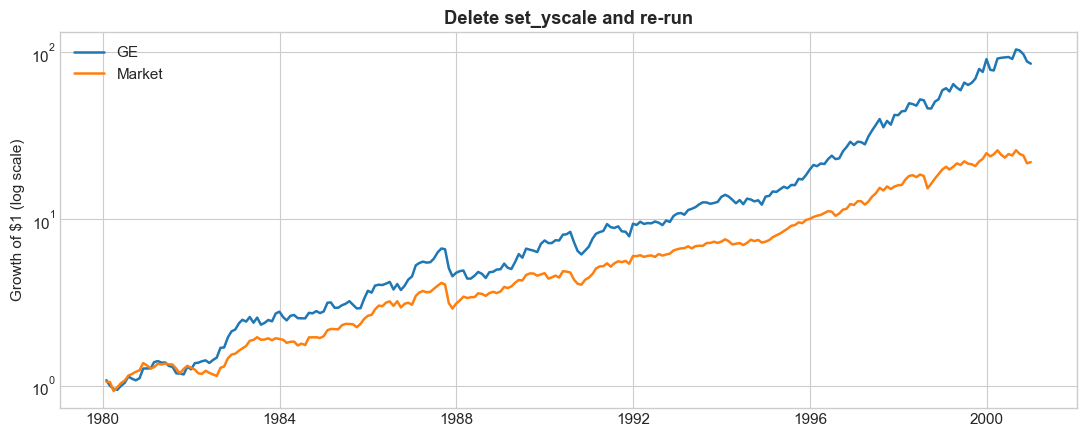

In [23]:
ge  = panel[panel.permno == 12060].set_index('date')['ret']
mkt = (ff['Mkt-RF'] + ff['RF']).reindex(ge.index)       # the market, at GE's dates (entry 10)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ge.index,  (1 + ge).cumprod(),  label='GE',     linewidth=1.8)
ax.plot(mkt.index, (1 + mkt).cumprod(), label='Market', linewidth=1.8)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('Delete set_yscale and re-run', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

### 22. A `for` loop and a dictionary <a id="forloop"></a>

> ```python
> months  = sorted(d['date'].unique())
> answers = {}
> for m in months:                                  # 251 times round
>     rows       = d[d.date == m]                   # just this month's stocks
>     weights    = rows['me_l1'] / rows['me_l1'].sum()
>     answers[m] = (weights * rows['ret']).sum()
> by_loop = pd.Series(answers)
> ```

The Appendix computes the value-weighted market the long way first, one month
at a time.

- `d['date'].unique()` lists each distinct date once, and `sorted(...)` puts
  that list in order.
- `answers = {}` is an empty dictionary (entry 15). `answers[m] = ...` adds an
  entry to it under the key `m`.
- `for m in months:` runs the indented lines under it once for every item in
  `months`, with `m` set to that item each time round. The indentation is what
  puts a line inside the loop; the first line that isn't indented runs after
  the loop has finished.
- `pd.Series(answers)` turns the finished dictionary into a Series. The keys
  become the labels.

Two more loops in the same lecture:

- `for m, rows in d.groupby('date'):` — looping over a `groupby` hands you, each
  time round, the key and that pile of rows as a DataFrame. `rows.shape` is its
  size: (rows, columns).
- `for k, v in cand.items():` — `.items()` goes through a dictionary as
  key–value pairs.

📍 **Used in:** the [Appendix on `groupby(...).apply`](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#groupby); `.items()`
in the Check cell of [build it yourself for the entire data set](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#build-it-yourself-for-the-entire-data-set).

In [24]:
toy = pd.DataFrame({'date': pd.to_datetime(['1995-01-31', '1995-01-31', '1995-02-28', '1995-02-28']),
                    'ret':  [0.10, 0.00, -0.05, 0.05]})

months  = sorted(toy['date'].unique())
answers = {}
for m in months:
    rows       = toy[toy.date == m]
    answers[m] = rows['ret'].mean()
    print("inside the loop: a month with", len(rows), "stocks")
print("after the loop\n")

print(pd.Series(answers), "\n")

for m, rows in toy.groupby('date'):
    print(m.date(), "->", type(rows).__name__, "of shape", rows.shape)

inside the loop: a month with 2 stocks
inside the loop: a month with 2 stocks
after the loop

1995-01-31    0.05
1995-02-28    0.00
dtype: float64 

1995-01-31 -> DataFrame of shape (2, 2)
1995-02-28 -> DataFrame of shape (2, 2)


### 23. `def`: a function with a name <a id="def"></a>

> ```python
> def vw_return(rows):
>     """Value-weighted return of one month's stocks."""
>     weights = rows['me_l1'] / rows['me_l1'].sum()
>     return (weights * rows['ret']).sum()
>
> by_named = d.groupby('date').apply(vw_return)
> ```

`def` makes a function of your own: a name, the input in parentheses, a colon,
then an indented body. `return` hands the result back to whoever called it. The
line in triple quotes just under `def` is a *docstring* — a description for
people, with no effect on what runs.

Once defined, it works like any other function: `vw_return(june)` on one month,
or `.apply(vw_return)` on every month — the same as entry 20's lambda, with a
name. A lambda is the throwaway version for one line; `def` is for anything
longer, or anything you will call again.

The Appendix ends by checking that its versions agree, with
`np.abs(s.values - by_loop.values).max()`. `.values` drops the labels, so the
subtraction goes by position rather than by date (entry 10); `np.abs` makes
every gap positive; `.max()` finds the largest. A gap in the eighth decimal
place is rounding in the computer's arithmetic, not a disagreement.

📍 **Used in:** the [Appendix on `groupby(...).apply`](https://amoreira2.github.io/UG54/chapters/Finance/L2_Panel_Portfolios_AI.html#groupby).

In [25]:
def vw_return(rows):
    """Value-weighted return of one month's stocks."""
    weights = rows['me_l1'] / rows['me_l1'].sum()
    return (weights * rows['ret']).sum()

june = d[d.date == '1995-06-30']
print(f"vw_return(june): {vw_return(june):.6f}   <- entry 19's number\n")

by_named = d.groupby('date').apply(vw_return)
print(f"largest gap between .apply(vw_return) and entry 20's lambda: "
      f"{np.abs(by_named.values - vw.values).max():.1e}")

vw_return(june): 0.031830   <- entry 19's number



largest gap between .apply(vw_return) and entry 20's lambda: 1.5e-08


---

## From *Sorts, Breakpoints, and Long-Short Portfolios*

### 24. `pd.read_csv`, and a base address <a id="readcsv"></a>

> ```python
> BASE  = "https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data"
> panel = pd.read_parquet(f"{BASE}/panel_backbone_1980_2000.parquet")
> menu  = pd.read_csv(f"{BASE}/signal_menu.csv")
> ```

CSV — comma-separated values — is the plainest table format there is: a text
file with one row per line and commas between the columns. Open one in a text
editor and you can read it. `pd.read_csv` loads it the way `pd.read_parquet`
loads a parquet file (entry 7).

`BASE` holds the part of the address that all the course files share, and each
load adds the rest with an f-string. The Hands-On uses the same trick with your
pick in the middle: `f"{BASE}/signals/{MY_SIGNAL}.parquet"`.

📍 **Used in:** the [Setup cell](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#setup) and
[Step 1 — The data](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#step-1-the-data).

In [26]:
BASE = "https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data"
print(f"{BASE}/signals/BM.parquet", "\n")          # what the f-string builds

menu = pd.read_csv(f"{BASE}/signal_menu.csv")
bm   = pd.read_parquet(f"{BASE}/signals/BM.parquet")
print(f"menu: {len(menu)} signals    bm: {len(bm):,} rows")
menu[['Acronym', 'Authors', 'Year', 'Cat.Economic']].head()

https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/signals/BM.parquet 



menu: 30 signals    bm: 1,174,870 rows


,Acronym,Authors,Year,Cat.Economic
0,OrgCap,Eisfeldt and Papanikolaou,2013,R&D
1,Accruals,Sloan,1996,accruals
2,NOA,Hirshleifer et al.,2004,asset composition
3,OScore,Dichev,1998,default risk
4,AnnouncementReturn,"Chan, Jegadeesh and Lakonishok",1996,earnings event


### 25. `.loc[rows, column]` <a id="loc2"></a>

> ```python
> print(menu.loc[menu.Acronym == 'BM', 'LongDescription'].iloc[0])
> ```

Entry 19 gave `.loc` one label. Given two things, `.loc[rows, column]` picks
rows and a column in one step. The rows can be a mask (entry 8); the column is
a name. What comes back here is a Series with one entry — the one signal whose
acronym is BM — and `.iloc[0]` (entry 3) takes the text out of it.

📍 **Used in:** [Step 1 — The data](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#step-1-the-data), and the
[Hands-On](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#ho1).

In [27]:
row = menu.loc[menu.Acronym == 'BM', 'LongDescription']
print(type(row).__name__)
print(row, "\n")
print(row.iloc[0])

Series
24    Book to market, original (Stattman 1980)
Name: LongDescription, dtype: object 

Book to market, original (Stattman 1980)


### 26. `.quantile`, and `np.exp` <a id="quantile"></a>

> ```python
> for q in [0.1, 0.5, 0.9]:
>     v = bm['BM'].quantile(q)
>     print(f"  {q:.0%} percentile: BM = {v:+.2f}   book / market = {np.exp(v):.2f}")
> ```

`.quantile(q)` is the value below which a share `q` of the data falls:
`.quantile(0.5)` is the median, `.quantile(0.1)` the 10th percentile.

`BM` is stored as a log. `np.exp` undoes a log, turning it back into the ratio
of book value to market value.

📍 **Used in:** [Step 1 — The data](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#step-1-the-data).

In [28]:
print(bm['BM'].quantile(0.5), "\n")
print(f"np.exp(-0.58) = {np.exp(-0.58):.2f}")

-0.584018886089325 

np.exp(-0.58) = 0.56


### 27. `.diff()`, `!=`, and slices <a id="diff"></a>

> ```python
> ge = bm[bm.permno == 12060].set_index('date')['BM']
> print(ge[ge.diff() != 0].iloc[1:7].round(3).to_string())
> ```

- `.diff()` is each value minus the one before it — the same as
  `x - x.shift(1)` (entry 17). Where `BM` didn't change, the difference is 0.
- `!=` means "not equal", so `ge[ge.diff() != 0]` keeps the months in which
  `BM` changed. The first row counts as changed: it has nothing before it, so
  its difference is `NaN`, and `NaN` is never equal to anything.
- `.iloc[1:7]` is a **slice**: positions 1 up to, *not including*, 7. It skips
  row 0 and keeps six rows. Leave out one side and the slice runs to the end:
  `[:3]` is the first three, `[-3:]` the last three.

Text slices the same way. In the Hands-On, `.iloc[0][:300]` prints the first
300 characters of a signal's description.

📍 **Used in:** [Step 1 — The data](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#step-1-the-data), and the
[Hands-On](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#ho1).

In [29]:
s = pd.Series([5, 5, 7, 7, 7, 9])
print(pd.DataFrame({'s': s, 'diff': s.diff(), 'changed': s.diff() != 0}).to_string(index=False), "\n")

print("iloc[1:4] :", s.iloc[1:4].tolist())
print("iloc[:3]  :", s.iloc[:3].tolist())
print("iloc[-3:] :", s.iloc[-3:].tolist())
print("text[:14] :", "Book to market, original (Stattman 1980)"[:14])

 s  diff  changed
 5   NaN     True
 5   0.0    False
 7   2.0     True
 7   0.0    False
 7   0.0    False
 9   2.0     True 

iloc[1:4] : [5, 7, 7]
iloc[:3]  : [5, 5, 7]
iloc[-3:] : [7, 7, 9]
text[:14] : Book to market


### 28. `merge`, and `.notna()` <a id="merge"></a>

> ```python
> d = panel.merge(bm, on=['permno', 'date'], how='left').sort_values(['permno', 'date'])
> ```

`merge` puts two tables side by side, matching rows on the columns named in
`on=`. Here a row of the panel and a row of `bm` belong together when both
`permno` *and* `date` agree, and the result has the panel's columns plus `BM`.

`how=` says what happens to a row with no partner:

- `how='left'` keeps every row of the left table — the one before `.merge` —
  and puts `NaN` in `BM` where there is no match.
- The default, `how='inner'`, keeps only the rows found in both.

The lecture uses `'left'` on purpose. The next line lags `BM` with a grouped
`.shift(1)`, which moves one *row* (entry 18). After an inner merge the months
without a `BM` are gone, so the row above can be a year back. After a left
merge every panel month is still there. `.sort_values` then restores the order
the shift needs.

`.notna()` is `True` where a value is present; `.isna()` is the opposite.

📍 **Used in:** [Step 1 — The data](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#step-1-the-data), and the
[🔒 Reference cell](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#demo).

In [30]:
left  = pd.DataFrame({'permno': [1, 1, 2], 'date': ['1995-01', '1995-02', '1995-01'],
                      'ret': [0.10, 0.02, -0.05]})
right = pd.DataFrame({'permno': [1, 2], 'date': ['1995-01', '1995-01'], 'BM': [0.4, 1.3]})

print("how='left'\n",  left.merge(right, on=['permno', 'date'], how='left').to_string(index=False), "\n")
print("how='inner'\n", left.merge(right, on=['permno', 'date']).to_string(index=False))

how='left'
  permno    date   ret  BM
      1 1995-01  0.10 0.4
      1 1995-02  0.02 NaN
      2 1995-01 -0.05 1.3 

how='inner'
  permno    date   ret  BM
      1 1995-01  0.10 0.4
      2 1995-01 -0.05 1.3


In [31]:
m_left  = panel.merge(bm, on=['permno', 'date'], how='left')
m_inner = panel.merge(bm, on=['permno', 'date'])

print(f"panel               {len(panel):>10,} rows")
print(f"how='left'          {len(m_left):>10,} rows")
print(f"how='inner'         {len(m_inner):>10,} rows\n")
print(f"share of panel rows with a BM: {m_left['BM'].notna().mean():.0%}")

panel                1,517,174 rows
how='left'           1,517,174 rows
how='inner'          1,174,870 rows

share of panel rows with a BM: 77%


### 29. `.transform`, and `pd.qcut` <a id="qcut"></a>

> ```python
> d['decile'] = d.groupby('date')['BM_l1'].transform(
>     lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))
> ```

`pd.qcut(x, 10)` cuts `x` into 10 groups with the same number of values in
each — equal-count buckets.

- `labels=False` numbers the buckets 0 to 9, instead of naming each by its range.
- `duplicates='drop'` covers the case where many identical values put two cut
  points on the same number. Rather than stop with an error, `qcut` merges those
  buckets, and you get fewer than 10.

Inside a `groupby('date')`, the cutting happens separately in each month:
ranking within the month, pitfall 4.

`.transform` is what lets the result go into a column. Entry 15's `.std()` and
entry 20's `.apply` give back **one number per pile**. `.transform` gives back
**one value per row**, in the original rows' order, so it can be stored as
`d['decile']` next to the data it came from.

📍 **Used in:** the [🔒 Reference cell](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#demo), and again in
[Why ten buckets?](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#tradeoff).

In [32]:
toy = pd.DataFrame({'date': ['1995-01'] * 4 + ['1995-02'] * 4,
                    'BM':   [0.1, 0.9, 0.5, 0.3,   2.0, 4.0, 1.0, 3.0]})

print("qcut over everything:", pd.qcut(toy['BM'], 4, labels=False).tolist(), "\n")
print("one number per month:\n" + toy.groupby('date')['BM'].mean().to_string(), "\n")

toy['bucket'] = toy.groupby('date')['BM'].transform(lambda x: pd.qcut(x, 4, labels=False))
print(toy.to_string(index=False), "\n")

ties = pd.Series([0, 0, 0, 0, 0, 1, 2, 3])
print("many ties, duplicates='drop':", pd.qcut(ties, 4, labels=False, duplicates='drop').tolist())

qcut over everything: [0, 1, 1, 0, 2, 3, 2, 3] 

one number per month:
date
1995-01    0.45
1995-02    2.50 

   date  BM  bucket
1995-01 0.1       0
1995-01 0.9       3
1995-01 0.5       2
1995-01 0.3       1
1995-02 2.0       1
1995-02 4.0       3
1995-02 1.0       0
1995-02 3.0       2 

many ties, duplicates='drop': [0, 0, 0, 0, 0, 0, 1, 1]


### 30. Grouping by two columns, and `.unstack()` <a id="unstack"></a>

> ```python
> bucket = d.groupby(['date', 'decile'])['ret'].mean().unstack()
> ls     = (bucket[9] - bucket[0]).dropna()
> ```

Given a list of columns, `groupby` makes one pile per **combination** — here,
one per month *and* decile, about 2,500 piles. `.mean()` gives one number per
pile, labelled by both: a two-level index, month then decile.

`.unstack()` takes the inner level of the labels and turns it into columns. The
long list becomes a table with one row per month and one column per decile.
`bucket[9]` is then the column **labelled** 9, the top decile, and
`bucket[9] - bucket[0]` is the long-short, month by month.

📍 **Used in:** the [🔒 Reference cell](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#demo), and every sort after it.

In [33]:
toy = pd.DataFrame({'date':   ['1995-01'] * 4 + ['1995-02'] * 4,
                    'decile': [0, 0, 9, 9, 0, 0, 9, 9],
                    'ret':    [0.01, 0.03, 0.05, 0.07, -0.02, 0.00, 0.04, 0.02]})

long = toy.groupby(['date', 'decile'])['ret'].mean()
print(long, "\n")

wide = long.unstack()
print(wide, "\n")
print((wide[9] - wide[0]).to_string())

date     decile
1995-01  0         0.02
         9         0.06
1995-02  0        -0.01
         9         0.03
Name: ret, dtype: float64 

decile      0     9
date               
1995-01  0.02  0.06
1995-02 -0.01  0.03 

date
1995-01    0.04
1995-02    0.04


In [34]:
# The lecture's whole 🔒 Reference cell — every line now has an entry
d = panel.merge(bm, on=['permno', 'date'], how='left').sort_values(['permno', 'date'])
d['BM_l1'] = d.groupby('permno')['BM'].shift(1)
d = d.dropna(subset=['BM_l1', 'ret', 'me_l1'])
d['decile'] = d.groupby('date')['BM_l1'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop'))

bucket = d.groupby(['date', 'decile'])['ret'].mean().unstack()
print(f"bucket: {bucket.shape[0]} months x {bucket.shape[1]} deciles")
bucket.head(3)

bucket: 251 months x 10 deciles


decile,0,1,2,3,4,5,6,7,8,9
date,,,,,,,,,,
1980-02-29,0.000213,0.006183,-0.019894,-0.015813,-0.019678,-0.034458,-0.025173,-0.019296,-0.018323,-0.012654
1980-03-31,-0.200088,-0.167063,-0.174782,-0.163206,-0.148029,-0.134785,-0.139556,-0.148362,-0.155921,-0.161044
1980-04-30,0.049759,0.050533,0.064747,0.059851,0.055221,0.056628,0.068934,0.052603,0.036178,0.029917


### 31. `range`, and two panels in one figure <a id="subplots2"></a>

> ```python
> for k in range(10):
>     print(f"  D{k+1:<2d} {bucket[k].mean()*12:7.2%}")
>
> fig, ax = plt.subplots(1, 2, figsize=(13, 4))
> ax[0].bar(range(1,11), bucket.mean()*12, color='steelblue')
> ax[1].plot(ls.index, (1+ls).cumprod(), color='darkorange', linewidth=1.8)
> ```

- `range(10)` counts 0, 1, …, 9: ten numbers, stopping *before* 10, like a
  slice (entry 27). `range(1, 11)` counts 1 to 10.
- `bucket.mean()` on a whole DataFrame averages **each column**: one mean
  return per decile.
- `plt.subplots(1, 2)` makes one row of two plotting areas. `ax` is now a pair:
  `ax[0]` is the left panel and `ax[1]` the right, and each takes the commands
  entry 14's single `ax` did.
- `ax.bar(x, heights)` draws bars — here the decile numbers 1 to 10 along the
  bottom, with their mean returns as the heights.

📍 **Used in:** the [🔒 Reference cell and the figure after it](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#demo).

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


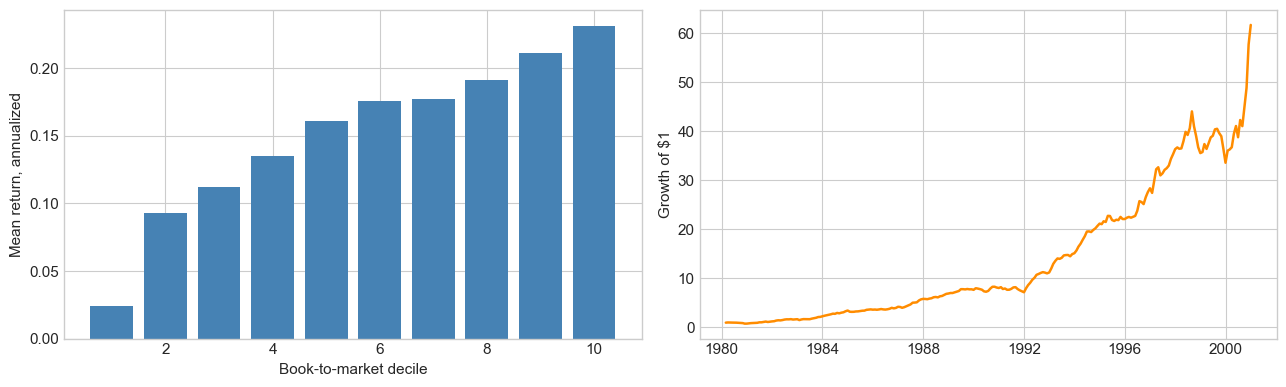

In [35]:
print(list(range(10)))
print(list(range(1, 11)))

ls = (bucket[9] - bucket[0]).dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, 11), bucket.mean() * 12, color='steelblue')
ax[0].set_xlabel('Book-to-market decile'); ax[0].set_ylabel('Mean return, annualized')
ax[1].plot(ls.index, (1 + ls).cumprod(), color='darkorange', linewidth=1.8)
ax[1].set_ylabel('Growth of $1')
plt.tight_layout(); plt.show()

### 32. `pd.set_option`, and sorting by a column <a id="setoption"></a>

> ```python
> pd.set_option('display.max_rows', 40, 'display.width', 200)
> menu[['Acronym','Authors','Year','Cat.Economic','T-Stat']].sort_values('Cat.Economic')
> ```

pandas shows a long table with the middle cut out and replaced by `...`.
`pd.set_option` changes how it displays things: here, up to 40 rows before it
cuts, and 200 characters of width before it wraps. Nothing in the data changes,
and the setting lasts until the runtime restarts.

`.sort_values('Cat.Economic')` sorts the rows by one column, alphabetically for
text. Entry 18 sorted by two.

📍 **Used in:** the [Hands-On: Pick Your Own Signal](https://amoreira2.github.io/UG54/chapters/Finance/L3_Sorts_AI.html#ho1).

In [36]:
pd.set_option('display.max_rows', 40, 'display.width', 200)
menu[['Acronym', 'Authors', 'Year', 'Cat.Economic', 'T-Stat']].sort_values('Cat.Economic')

,Acronym,Authors,Year,Cat.Economic,T-Stat
0,OrgCap,Eisfeldt and Papanikolaou,2013,R&D,2.850000
1,Accruals,Sloan,1996,accruals,4.710000
2,NOA,Hirshleifer et al.,2004,asset composition,8.450000
3,OScore,Dichev,1998,default risk,3.360000
4,AnnouncementReturn,"Chan, Jegadeesh and Lakonishok",1996,earnings event,9.250000
5,ShareIss5Y,Daniel and Titman,2006,external financing,4.390000
6,ShareIss1Y,Pontiff and Woodgate,2008,external financing,7.080000
7,CompositeDebtIssuance,"Lyandres, Sun and Zhang",2008,external financing,8.590000
8,AssetGrowth,"Cooper, Gulen and Schill",2008,investment,8.450000
9,InvestPPEInv,"Lyandres, Sun and Zhang",2008,investment,7.130000


---

*Entries for* Performance Evaluation, and Factor Models *are added after that
lecture.*